In [1]:
import pandas as pd
import numpy as np

pattern = pd.read_csv('/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/scripts/01-18-2024_batch_structure_snap/Gahnite.xy', header=None)
pattern = pattern.values
pattern_domain = pattern[:,0]
pattern_intensity = pattern[:,1]
print(pattern_intensity)

[35. 58. 43. ... 66. 50. 59.]


In [2]:
from pymatgen.core.structure import Structure
structure = Structure.from_file('/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/scripts/01-18-2024_batch_structure_snap/Gahnite.cif')
print(len(structure.frac_coords))
number_atom_types = []
for i in range(len(structure.species)):
    number_atom_types.append(structure.species[i].number)
print(number_atom_types)
print(structure.species)
print(structure.lattice)

56
[13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 30, 30, 30, 30, 30, 30, 30, 30, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
[Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Al, Element Zn, Element Zn, Element Zn, Element Zn, Element Zn, Element Zn, Element Zn, Element Zn, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O, Element O]
8.085400 0.000000 0.000000
-0.000000 8.085400 0.000000
0.000000 0.000000 8.085400


In [1]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

In [2]:
import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
#from torch_geometric.data import Batch
#from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from scripts.eval_utils import load_model

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []

In [3]:
from hydra.experimental import compose
from hydra import initialize_config_dir

model_path = Path("/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/conf/")

with initialize_config_dir(str(model_path)):
    cfg = compose(config_name = 'default')
    datamodule = hydra.utils.instantiate(
        cfg.data.datamodule, _recursive_=False, scaler_path=None
    )
    datamodule.setup('test')
    test_loader = datamodule.test_dataloader()[0]

loader = test_loader

/home/gridsan/eriesel/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/train_20_any.csv
using existing graph file  /home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/train_20_any.pt
no filter
using 27136 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/train_xrd_peak_intensities_dict.pt'
time taken: 14.395725727081299


/data1/groups/Freedman_CDVAE/XRD_CDVAE_Repo/cdvae/common/data_utils.py:617: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)


constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/test_20_any.csv
using existing graph file  /home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/test_20_any.pt
no filter
using 9047 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/data/mp_20/test_xrd_peak_intensities_dict.pt'
time taken: 4.626316785812378


In [4]:
list_of_idxs = []
list_of_batchs = []

for idx, batch in enumerate(loader):
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]

def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    disc_sim_xrd = batch_reserve[4]
    batch = batch[0]
    return batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch

batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch = new_dataloader_batch_processor(batch)

batch = batch.cuda()

batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []

In [8]:
#NOTE THE INTENSITIES WILL LOOK WRONG IF THE DOMAIN IS SET TOO WIDE WITH TOO FEW STEPS

import diffraction as dc
from math import pi
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator


q_max = 8
wavelength = 1.54184
max_two_theta = 90
print("The pattern will be accurate out to:", np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi)


#DC = dc.diffraction_calculator(q_max=10, q_step=0.1, q_width=0.1, wavelength=1.0, device='cpu')
DC = dc.diffraction_pattern(q_max= q_max, wavelength= wavelength)


mini_batch_size = 8
if batch['angles'].size()[0] % mini_batch_size != 0:
    print("set mini_batch_size to be multiplicative factor of the batch size")



patterns = DC.batch_split_diffraction_calc(batch, mini_batch_size)
scan, domain = DC.bin_pattern_theta(patterns, num_steps = 256)
print(scan.size())


pymat_pattern = DC.pymatgen_pattern(pattern[:,0,:])[2:]









pymat_pattern[:,1] = pymat_pattern[:,1]/ torch.max(pymat_pattern[:,1])

scan, domain = DC.bin_pattern_theta(pattern, num_steps = 2560)



plt.plot(domain.cpu().detach().numpy(), scan[0].cpu().detach().numpy() / torch.max(scan[0]).cpu().detach().numpy())
plt.xlim(0,max_two_theta)
plt.show()
plt.close()



batch = {
    'angles': torch.tensor([[90.0,90.0,90.0]], requires_grad = False).cuda(),
    'lengths': torch.tensor([[7.9, 8.085400, 8.0]], requires_grad = False).cuda(),
    'frac_coords': torch.tensor(structure.frac_coords, dtype = torch.float, requires_grad = False).cuda(),
    'num_atoms': torch.tensor([56]).cuda(),
    'atom_types': torch.tensor(number_atom_types).cuda()
}

batch['lengths'] = batch['lengths'].clone().detach().requires_grad_(True)
batch['angles'] = batch['angles'].clone().detach().requires_grad_(True)
batch['frac_coords'] = batch['frac_coords'].clone().detach().requires_grad_(True)


pattern_intensity = torch.tensor(pattern_intensity).requires_grad_(False).cuda()


q_min = 4 * pi * np.sin(pattern_domain[0] * pi / 360) / wavelength
q_max = 4 * pi * np.sin(pattern_domain[-1] * pi / 360) / wavelength

print(DC.snap_structure(pattern_intensity, batch, iterations = 10000, learning_rate = 0.0005, U = 0, V = 0, W = 10, sharpen_rate = 0.0001, plot_progress = True, plot_freq = 200))
#print(DC.snap_structure(pattern_intensity, batch, iterations = 10000, learning_rate = 0.0005, U = 0, V = 0, W = 10, sharpen_rate = 0.0001, plot_progress = True, plot_freq = 200, q_min = q_min, q_max = q_max))





"""
max_r = self.q_max / (2 * pi)
max_recip_length = q_max /2pi
two theta = 360 / pi * arcsin(wavelength * recip_length / 2)"""


"""
pattern[1][0][3].backward()
#print(pattern[:,0,:])
#print(batch['angles'][0])
print(batch['angles'].grad)
#print(batch['frac_coords'][0])
print(batch['frac_coords'].grad)
#scan = DC.bin_pattern_theta(pattern)
#print(scan)
#plt.plot(scan)"""

The pattern will be accurate out to: 157.96318411669148
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([2, 8, 4934])
torch.Size([256, 256])


NameError: name 'pattern' is not defined

The pattern will be accurate out to: 157.96318411669148
set mini_batch_size to be multiplicative factor of the batch size


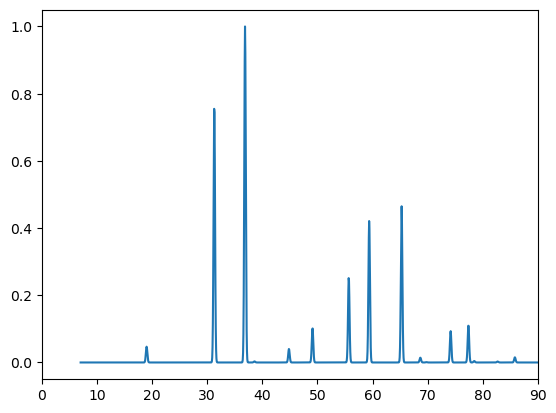

/state/partition1/slurm_tmp/24757445.0.0/ipykernel_2235978/2429311732.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pattern_intensity = torch.tensor(pattern_intensity).requires_grad_(False).cuda()


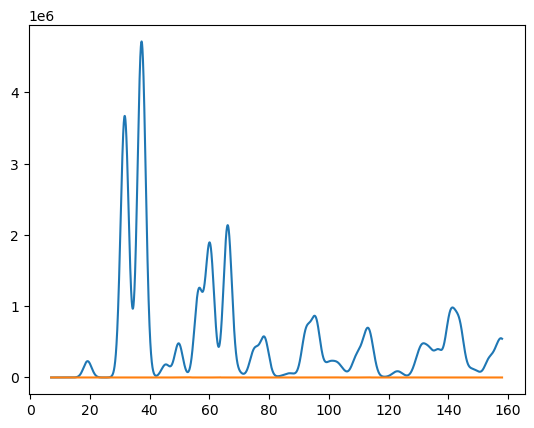

Step 1: Lengths - tensor([[7.9000, 8.0855, 8.0000]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01, -3.5153e-12, -1.9731e-12],
        [ 1.0340e-12,  5.0000e-01, -3.8017e-12],
        [-3.8856e-12, -4.7465e-12,  5.0000e-01],
        [ 2.5000e-01, -1.1743e-11,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01, -4.2850e-12,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-7.7062e-12,  2.5000e-01,  7.5000e-01],
        [-8.7762e-12,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01, -1.2866e-11],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01, -6.9067e-12],
        [ 1.2500e-01,  1.2500e-01,  1.

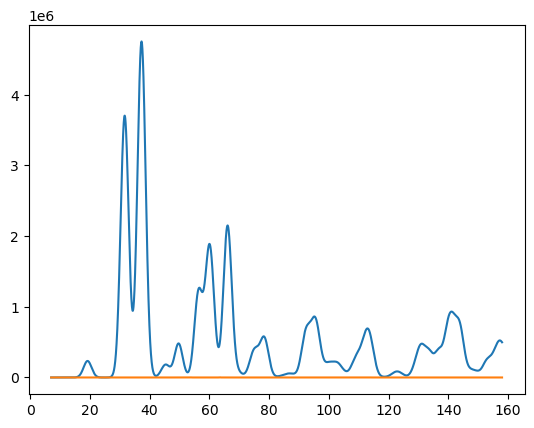

Step 201: Lengths - tensor([[7.8963, 8.0961, 8.0037]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01,  6.3039e-10,  3.8652e-09],
        [-1.8243e-09,  5.0000e-01,  4.3329e-09],
        [-1.4688e-09, -6.4444e-11,  5.0000e-01],
        [ 2.5000e-01, -7.9763e-11,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01,  7.0238e-10,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-1.4110e-09,  2.5000e-01,  7.5000e-01],
        [-1.5755e-09,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  3.5011e-09],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  4.3878e-09],
        [ 1.2500e-01,  1.2500e-01,  

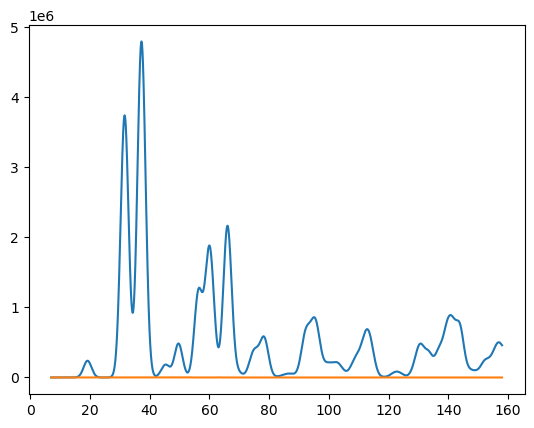

Step 401: Lengths - tensor([[7.8925, 8.1069, 8.0076]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01,  5.1094e-09,  4.2354e-08],
        [-5.7636e-09,  5.0000e-01,  4.3479e-08],
        [-1.5828e-09, -1.5835e-09,  5.0000e-01],
        [ 2.5000e-01,  1.9647e-09,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01,  2.5328e-09,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-2.7432e-09,  2.5000e-01,  7.5000e-01],
        [-3.0814e-09,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  4.0751e-08],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  4.2513e-08],
        [ 1.2500e-01,  1.2500e-01,  

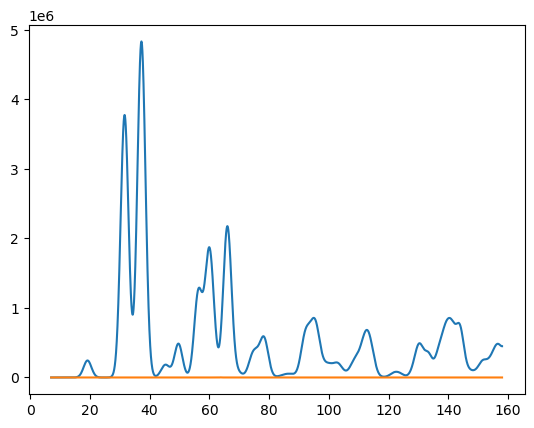

Step 601: Lengths - tensor([[7.8887, 8.1179, 8.0119]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01,  1.0769e-08,  1.1457e-07],
        [-1.2658e-08,  5.0000e-01,  1.1630e-07],
        [-3.7073e-09, -7.0374e-09,  5.0000e-01],
        [ 2.5000e-01,  3.7617e-09,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01,  4.1393e-09,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-3.4923e-09,  2.5000e-01,  7.5000e-01],
        [-5.7461e-09,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  1.1270e-07],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  1.1533e-07],
        [ 1.2500e-01,  1.2500e-01,  

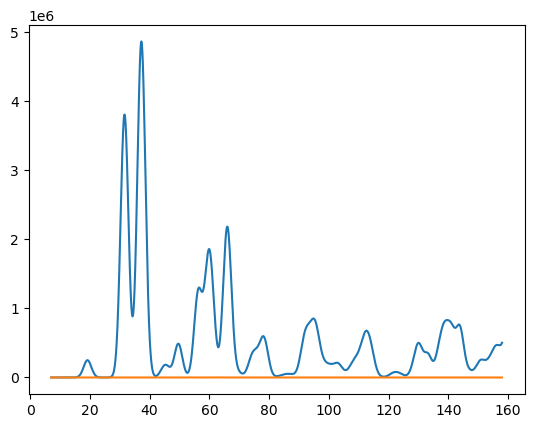

Step 801: Lengths - tensor([[7.8849, 8.1298, 8.0166]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01,  1.6141e-08,  2.1685e-07],
        [-2.3116e-08,  5.0000e-01,  2.2061e-07],
        [-7.4116e-09, -2.0732e-08,  5.0000e-01],
        [ 2.5000e-01,  2.5858e-09,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01,  2.5500e-09,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-4.0810e-09,  2.5000e-01,  7.5000e-01],
        [-6.6384e-09,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  2.1580e-07],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  2.2020e-07],
        [ 1.2500e-01,  1.2500e-01,  

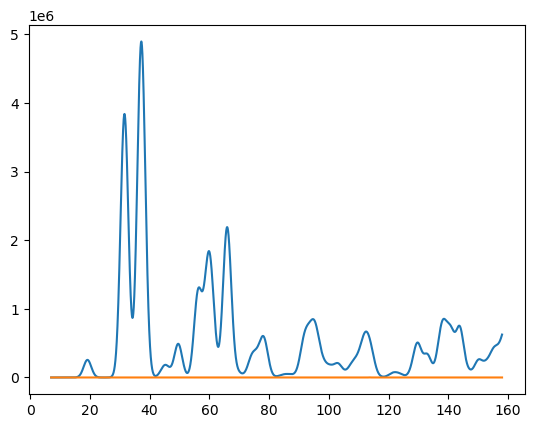

Step 1001: Lengths - tensor([[7.8810, 8.1433, 8.0221]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01, -1.8566e-08,  3.1919e-07],
        [-3.9269e-08,  5.0000e-01,  3.2921e-07],
        [-1.2035e-08, -7.8030e-08,  5.0000e-01],
        [ 2.5000e-01, -3.8955e-08,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01, -3.7242e-08,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-4.9322e-09,  2.5000e-01,  7.5000e-01],
        [-5.8190e-09,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  3.1950e-07],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  3.2530e-07],
        [ 1.2500e-01,  1.2500e-01, 

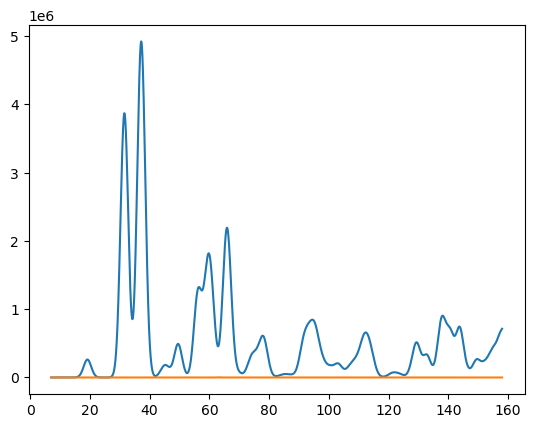

Step 1201: Lengths - tensor([[7.8772, 8.1583, 8.0282]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01, -5.5647e-08,  4.3012e-07],
        [-5.8024e-08,  5.0000e-01,  4.5070e-07],
        [-1.8138e-08, -1.4359e-07,  5.0000e-01],
        [ 2.5000e-01, -8.3586e-08,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01, -8.1592e-08,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-6.0626e-09,  2.5000e-01,  7.5000e-01],
        [-3.0579e-09,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  4.3267e-07],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  4.4021e-07],
        [ 1.2500e-01,  1.2500e-01, 

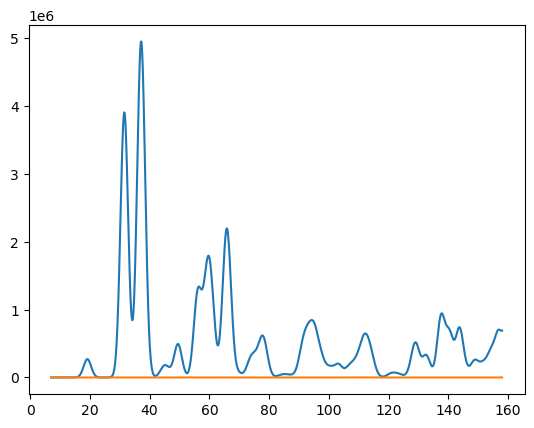

Step 1401: Lengths - tensor([[7.8735, 8.1742, 8.0347]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01, -9.0994e-08,  5.4778e-07],
        [-7.8191e-08,  5.0000e-01,  5.8451e-07],
        [-2.8943e-08, -2.1506e-07,  5.0000e-01],
        [ 2.5000e-01, -1.2960e-07,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01, -1.2697e-07,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-7.2252e-09,  2.5000e-01,  7.5000e-01],
        [-7.4434e-10,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  5.5271e-07],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  5.6477e-07],
        [ 1.2500e-01,  1.2500e-01, 

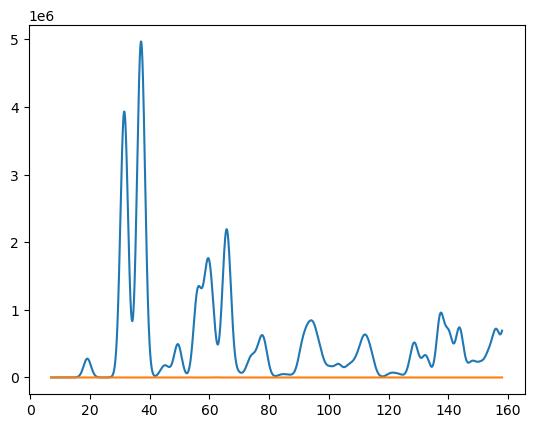

Step 1601: Lengths - tensor([[7.8704, 8.1911, 8.0414]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01, -1.2284e-07,  6.7114e-07],
        [-1.0208e-07,  5.0000e-01,  7.2883e-07],
        [-4.4825e-08, -2.8886e-07,  5.0000e-01],
        [ 2.5000e-01, -1.7696e-07,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01, -1.7180e-07,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-8.5491e-09,  2.5000e-01,  7.5000e-01],
        [ 2.7377e-09,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  6.7996e-07],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  6.9762e-07],
        [ 1.2500e-01,  1.2500e-01, 

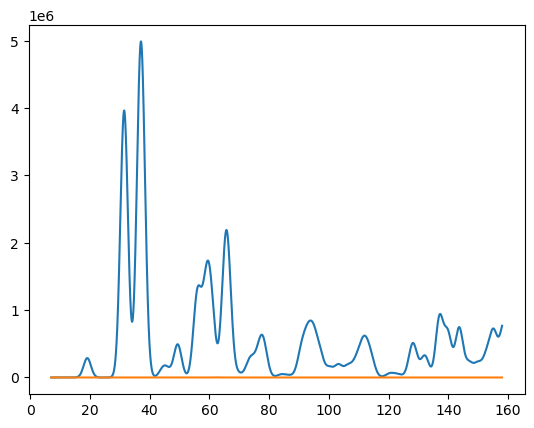

Step 1801: Lengths - tensor([[7.8680, 8.2096, 8.0488]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01, -1.5217e-07,  8.0233e-07],
        [-1.2787e-07,  5.0000e-01,  8.8900e-07],
        [-6.6953e-08, -3.6299e-07,  5.0000e-01],
        [ 2.5000e-01, -2.2266e-07,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01, -2.1323e-07,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-9.9636e-09,  2.5000e-01,  7.5000e-01],
        [ 5.7622e-09,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  8.1627e-07],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  8.3946e-07],
        [ 1.2500e-01,  1.2500e-01, 

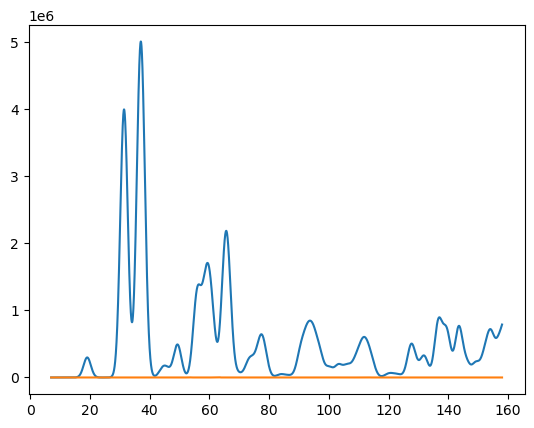

Step 2001: Lengths - tensor([[7.8662, 8.2291, 8.0576]], device='cuda:0', requires_grad=True), Angles - tensor([[90., 90., 90.]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 5.0000e-01,  5.0000e-01,  5.0000e-01],
        [ 5.0000e-01, -1.8059e-07,  9.2934e-07],
        [-1.5699e-07,  5.0000e-01,  1.0524e-06],
        [-9.6062e-08, -4.3277e-07,  5.0000e-01],
        [ 2.5000e-01, -2.6553e-07,  7.5000e-01],
        [ 2.5000e-01,  5.0000e-01,  2.5000e-01],
        [ 7.5000e-01, -2.5095e-07,  2.5000e-01],
        [ 7.5000e-01,  5.0000e-01,  7.5000e-01],
        [-1.1075e-08,  2.5000e-01,  7.5000e-01],
        [ 1.0293e-08,  7.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  2.5000e-01,  2.5000e-01],
        [ 5.0000e-01,  7.5000e-01,  7.5000e-01],
        [ 2.5000e-01,  7.5000e-01,  9.4933e-07],
        [ 2.5000e-01,  2.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  7.5000e-01,  5.0000e-01],
        [ 7.5000e-01,  2.5000e-01,  9.8171e-07],
        [ 1.2500e-01,  1.2500e-01, 

KeyboardInterrupt: 

In [5]:
#NOTE THE INTENSITIES WILL LOOK WRONG IF THE DOMAIN IS SET TOO WIDE WITH TOO FEW STEPS

import diffraction as dc
from math import pi
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator


batch = {
    'angles': torch.tensor([[90.0,90.0,90.0]], requires_grad = False).cuda(),
    'lengths': torch.tensor([[8.085400, 8.085400, 8.085400]], requires_grad = False).cuda(),
    'frac_coords': torch.tensor(structure.frac_coords, dtype = torch.float, requires_grad = False).cuda(),
    'num_atoms': torch.tensor([56]).cuda(),
    'atom_types': torch.tensor(number_atom_types).cuda()
}


q_max = 8
wavelength = 1.54184
max_two_theta = 90
print("The pattern will be accurate out to:", np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi)


#DC = dc.diffraction_calculator(q_max=10, q_step=0.1, q_width=0.1, wavelength=1.0, device='cpu')
DC = dc.diffraction_pattern(q_max= q_max, wavelength= wavelength)


mini_batch_size = 8
if batch['angles'].size()[0] % mini_batch_size != 0:
    print("set mini_batch_size to be multiplicative factor of the batch size")



pattern = DC.diffraction_calc(batch, indices = [0,8])

pymat_pattern = DC.pymatgen_pattern(pattern[:,0,:])[2:]
pymat_pattern[:,1] = pymat_pattern[:,1]/ torch.max(pymat_pattern[:,1])

scan, domain = DC.bin_pattern_theta(pattern, num_steps = 2560)



plt.plot(domain.cpu().detach().numpy(), scan[0].cpu().detach().numpy() / torch.max(scan[0]).cpu().detach().numpy())
plt.xlim(0,max_two_theta)
plt.show()
plt.close()



batch = {
    'angles': torch.tensor([[90.0,90.0,90.0]], requires_grad = False).cuda(),
    'lengths': torch.tensor([[7.9, 8.085400, 8.0]], requires_grad = False).cuda(),
    'frac_coords': torch.tensor(structure.frac_coords, dtype = torch.float, requires_grad = False).cuda(),
    'num_atoms': torch.tensor([56]).cuda(),
    'atom_types': torch.tensor(number_atom_types).cuda()
}

batch['lengths'] = batch['lengths'].clone().detach().requires_grad_(True)
batch['angles'] = batch['angles'].clone().detach().requires_grad_(True)
batch['frac_coords'] = batch['frac_coords'].clone().detach().requires_grad_(True)


pattern_intensity = torch.tensor(pattern_intensity).requires_grad_(False).cuda()


q_min = 4 * pi * np.sin(pattern_domain[0] * pi / 360) / wavelength
q_max = 4 * pi * np.sin(pattern_domain[-1] * pi / 360) / wavelength

print(DC.snap_structure(pattern_intensity, batch, iterations = 10000, learning_rate = 0.0005, U = 0, V = 0, W = 10, sharpen_rate = 0.0001, plot_progress = True, plot_freq = 200))
#print(DC.snap_structure(pattern_intensity, batch, iterations = 10000, learning_rate = 0.0005, U = 0, V = 0, W = 10, sharpen_rate = 0.0001, plot_progress = True, plot_freq = 200, q_min = q_min, q_max = q_max))





"""
max_r = self.q_max / (2 * pi)
max_recip_length = q_max /2pi
two theta = 360 / pi * arcsin(wavelength * recip_length / 2)"""


"""
pattern[1][0][3].backward()
#print(pattern[:,0,:])
#print(batch['angles'][0])
print(batch['angles'].grad)
#print(batch['frac_coords'][0])
print(batch['frac_coords'].grad)
#scan = DC.bin_pattern_theta(pattern)
#print(scan)
#plt.plot(scan)"""